# How to generate `Alpha` channel with transparency
- `Alpha` channel: The `display ratio of this image` relative to the background ₩

- 0 : none of this image $\rightarrow$ only background $\rightarrow$ transparent

- 255: only this image $\rightarrow$ no background $\rightarrow$ non-transparent


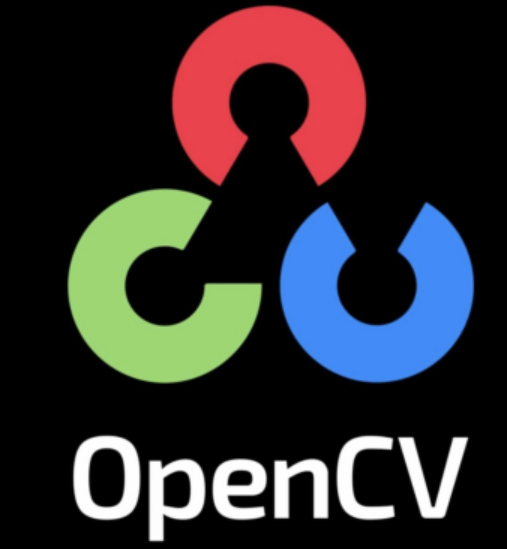

(681, 613, 3) uint8


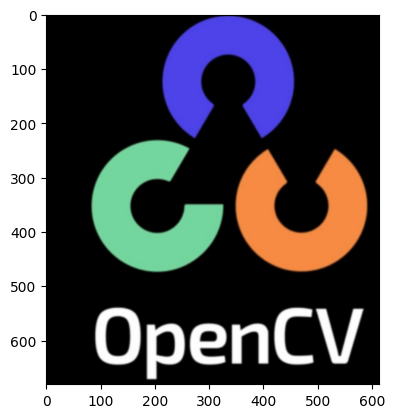

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

src = cv2.imread('images/Opencv-logo.jpg')

print(src.shape, src.dtype)
plt.imshow(src)
plt.show()

### Create a new image with alpha channe where black will be masked out (transparent)

#### 1. Generate a matrix to select corresponding pixels including the desired color (Black)

(681, 613, 3)


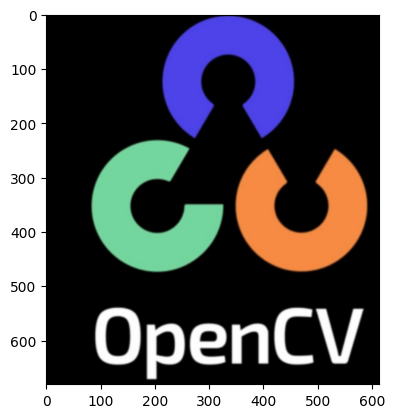

uint8
(681, 613, 3)


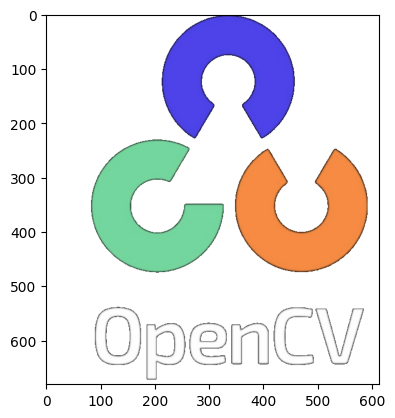

In [22]:
thr = 50

rgb = src[:, :, :3]
print(rgb.shape)
plt.imshow(rgb)
plt.show()
locs = (rgb[:, :, 0] < thr) & (rgb[:, :, 1] < thr) & (rgb[:, :, 2] < thr)

src_tmp = rgb.copy()
# print(src_tmp.dtype)
# src_tmp = np.where(src_tmp < 50 , 255, 0)
src_tmp[locs] = [255,255,255]

print(src_tmp.dtype)
print(src_tmp.shape)
plt.imshow(src_tmp)
plt.show()


#### 2. Generate `alpha channel`
- Black pixels should be `transparent`
- The corresponding pixels in the alpha channel should be `zero`.

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


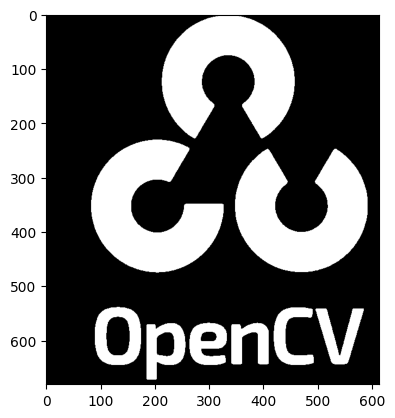

In [23]:
# alpha = 
locs = ~locs
print(locs)
locs =locs.astype(np.uint8)
locs *=50

plt.imshow(locs, cmap="gray")
plt.show()

#### 3. Concatenate the alpha channel to the original image in the axis=3
- `New image will have four channels`


- np.vstack: Stacks along Axis=0 (`Rows`)
- np.hstack: Stacks along Axis=1 (`Columns`)
- np.dstack: Stacks along Axis=2 (`Depth`)

(681, 613, 1)


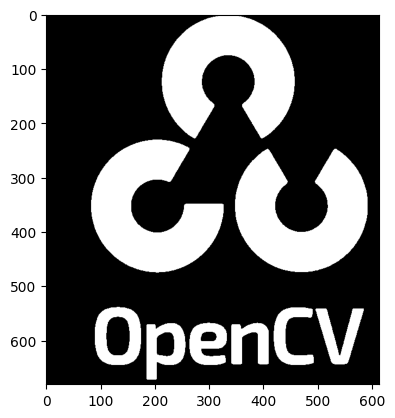

(681, 613, 4)


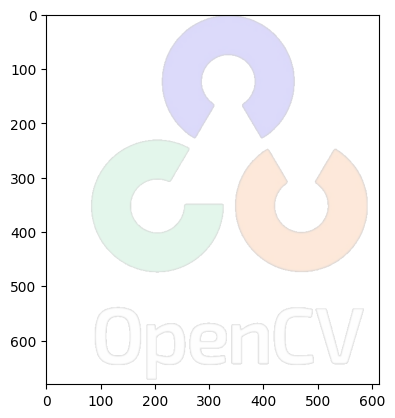

저장 완료: src_2.png


In [38]:
new_chanel = locs.reshape(681, 613,1)
print(new_chanel.shape)
plt.imshow(new_chanel, cmap="gray")
plt.show()

src_2 = np.dstack((src, new_chanel))
print(src_2.shape)

plt.imshow(src_2)
plt.show()
plt.imsave("images/src_2.png", src_2)
print("저장 완료: src_2.png")